**Hidden Markov Model**

Paulo Yoshio Kuga

In this notebook, we are going to show how to train the HMM model with lissa.

In [1]:
#import libraries

import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

import hmmlearn.hmm as hmm

import lissa as li

from sklearn.mixture import GaussianMixture

In [2]:
#You also can read data without processing it always:

totalData = pd.read_csv("../data/totalProcessedData.csv",delimiter=",").fillna(0)
totalData.rename(columns={"index":"time"},inplace=True)
totalData.drop(columns=["Unnamed: 0"],inplace=True)

/tmp/ipykernel_279597/2621100290.py:3: DtypeWarning: Columns (16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  totalData = pd.read_csv("../data/totalProcessedData.csv",delimiter=",").fillna(0)


Then, a list of properties is obtained through copy and paste of previous $list(entireData)$

In [3]:
Headers = [
    #'ESP discharge temperature sensor',
    'ESP intake temperature',
    'ESP motor temperature',
    'Well head Temperature',
    'ESP intake Pressure',
    'ESP discharge pressure',
    #'ESP differential pressure',
    'Well head pressure',
    'VSD power frequency',
    'ESP Motor Voltage',
    'ESP Current Module',
    #'ESP Vibration X',
    #'ESP Vibration Y',
    'ESP Vibration Module'
    #'ESP Power',
    #"Well_down"
    ]

pumpList = totalData["Well Run"].unique()

In [4]:
mainSeed = 971215
np.random.seed(mainSeed)

totalData["Choke Closed"] = 1-totalData["Choke Opening"]
totalData["Radius"] = totalData[Headers].pow(2).sum(axis=1).pow(1/2)

X_train, trainLength, X_test, testLength, modelData, totalLength = li.Splitter(pumpList=pumpList,proportion=0.75,entireData=totalData)

GMM AIC: 3089833.962025039
GMM BIC: 3089927.160911842


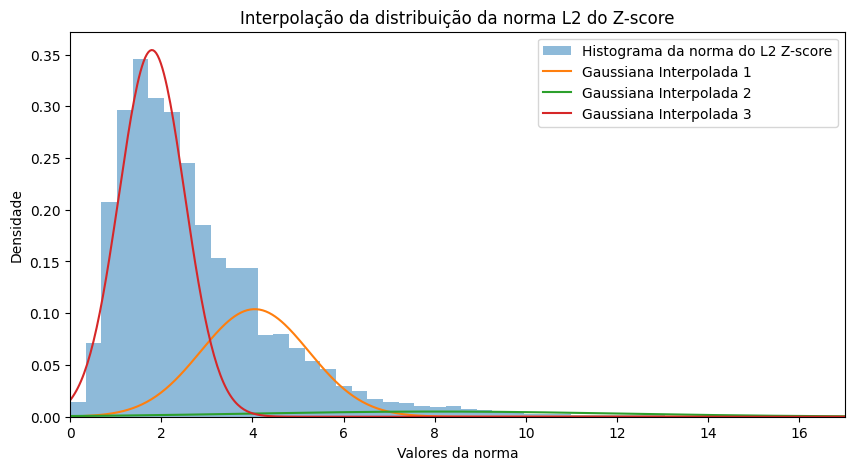

[0.30963485 0.05043931 0.63992584]


In [60]:
n = 3
radiusData = totalData["Radius"].loc[totalData["Well_down"]==0]

model = li.GaussianMixtureFit(radiusData,n,seed=mainSeed)

li.GaussianMixturePlot(radiusData,model,[
    "Histograma da norma do L2 Z-score",
    "Gaussiana Interpolada",
    "Interpolação da distribuição da norma L2 do Z-score",
    "Valores da norma",
    "Densidade"],
    figsize=(10,5))

print(model.weights_)

In [6]:
modelRadius = hmm.GaussianHMM(
    n_components=n,
    random_state=mainSeed,
    covariance_type="full",
    #params="st",
    init_params="st",
    algorithm="viterbi"
    )

modelRadius.means_ = model.means_
modelRadius.covars__ = model.covariances_


modelRadius = li.HMMTrainer(X_train["Radius"],trainLength,modelRadius)

li.PostProcessing(modelRadius, totalData, modelData,"Radius", "State Radius", totalLength)
print(modelRadius.get_stationary_distribution())
totalData["State Radius"] = totalData["State Radius"].map(li.StateConversion(modelRadius.get_stationary_distribution(),n))



AIC: 1858380.0305977152 BIC: 1858543.1286496199
[0.23658076 0.07888897 0.68453028]


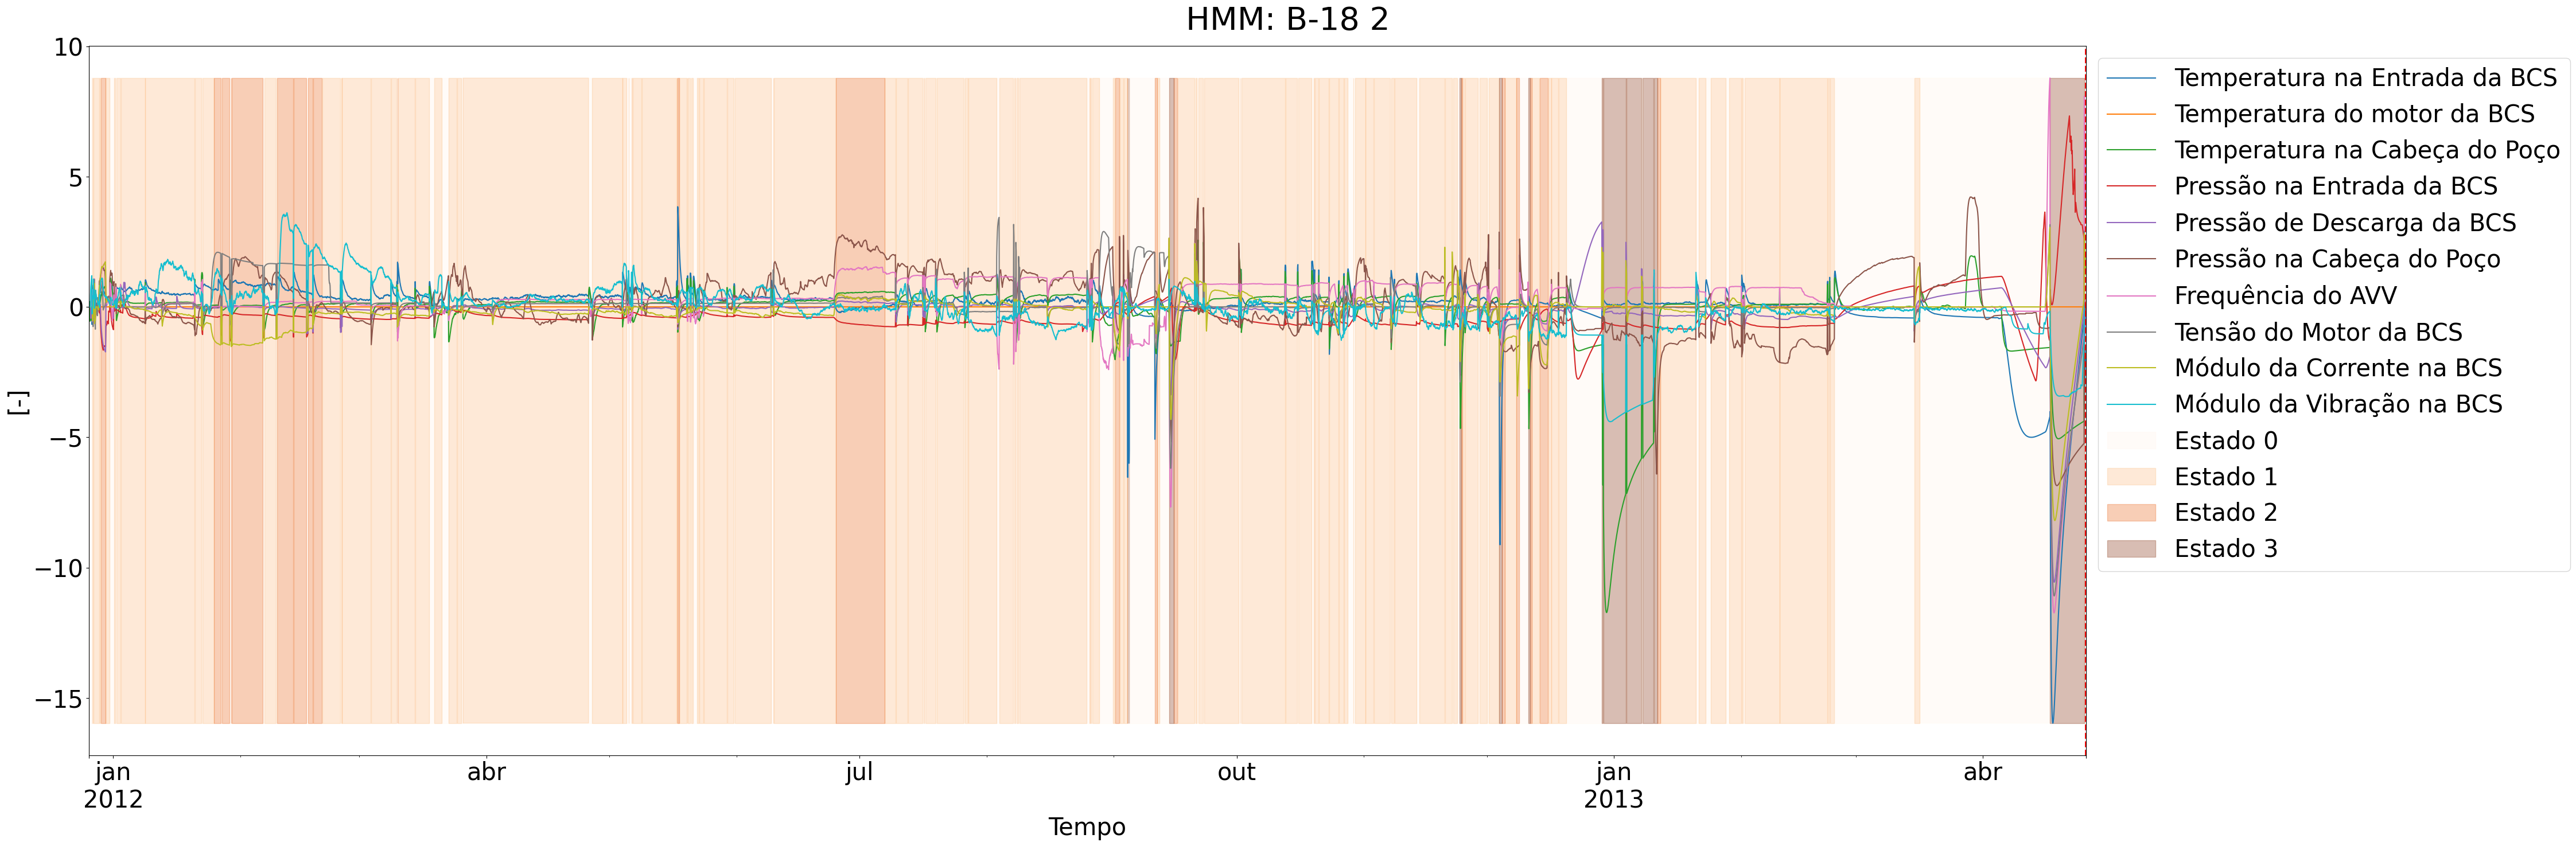

In [7]:
pump = pumpList[0]

#b-18 2
#a-12 2
#a-29 2

pumpData = totalData.loc[totalData["Well Run"]==pump].copy()

pumpData["time"] = pd.to_datetime(pumpData["time"])
pumpData.set_index("time",inplace=True)
pumpData = pumpData.asfreq('h',fill_value=0)
    

fig,axs = li.HMMPicture(pumpData,pump,Headers=Headers,measures='[-]',states="State Radius", numberOfStates=n, figsize=(45,15),english=False,gnrlFont=30,titleFont=40)
axs.set_xlabel("Tempo")



fig.savefig("../imagens_gerais/pumps/"+pump+"markovrun.jpg")


In [8]:
for pump in pumpList:
    pumpData = totalData.loc[totalData["Well Run"]==pump].copy()
    pumpData["time"] = pd.to_datetime(pumpData["time"])
    pumpData.set_index("time",inplace=True)
    pumpData = pumpData.asfreq('h',fill_value=0)
    
    fig,axs = li.HMMPicture(pumpData,pump,Headers=Headers,measures='[-]',states="State Radius", numberOfStates=n, figsize=(45,15),english=False,gnrlFont=30,titleFont=40)
    plt.rcParams["font.size"]=20
    axs.set_xlabel("Tempo")

    fig.savefig("../imagens_gerais/pumps/"+pump+"markovrun.jpg")
    plt.close()

In [9]:
medianListR = np.array([])

for pump in pumpList:
    pumpData = totalData.loc[(totalData["Well Run"]==pump) & (totalData["Well_down"]==0) ]#.copy()
    last = pumpData.shape[0]
    pumpMedianR = pumpData.loc[pumpData.index[last-24:last-1],"State Radius"].median()
    medianListR = np.append(medianListR,pumpMedianR)




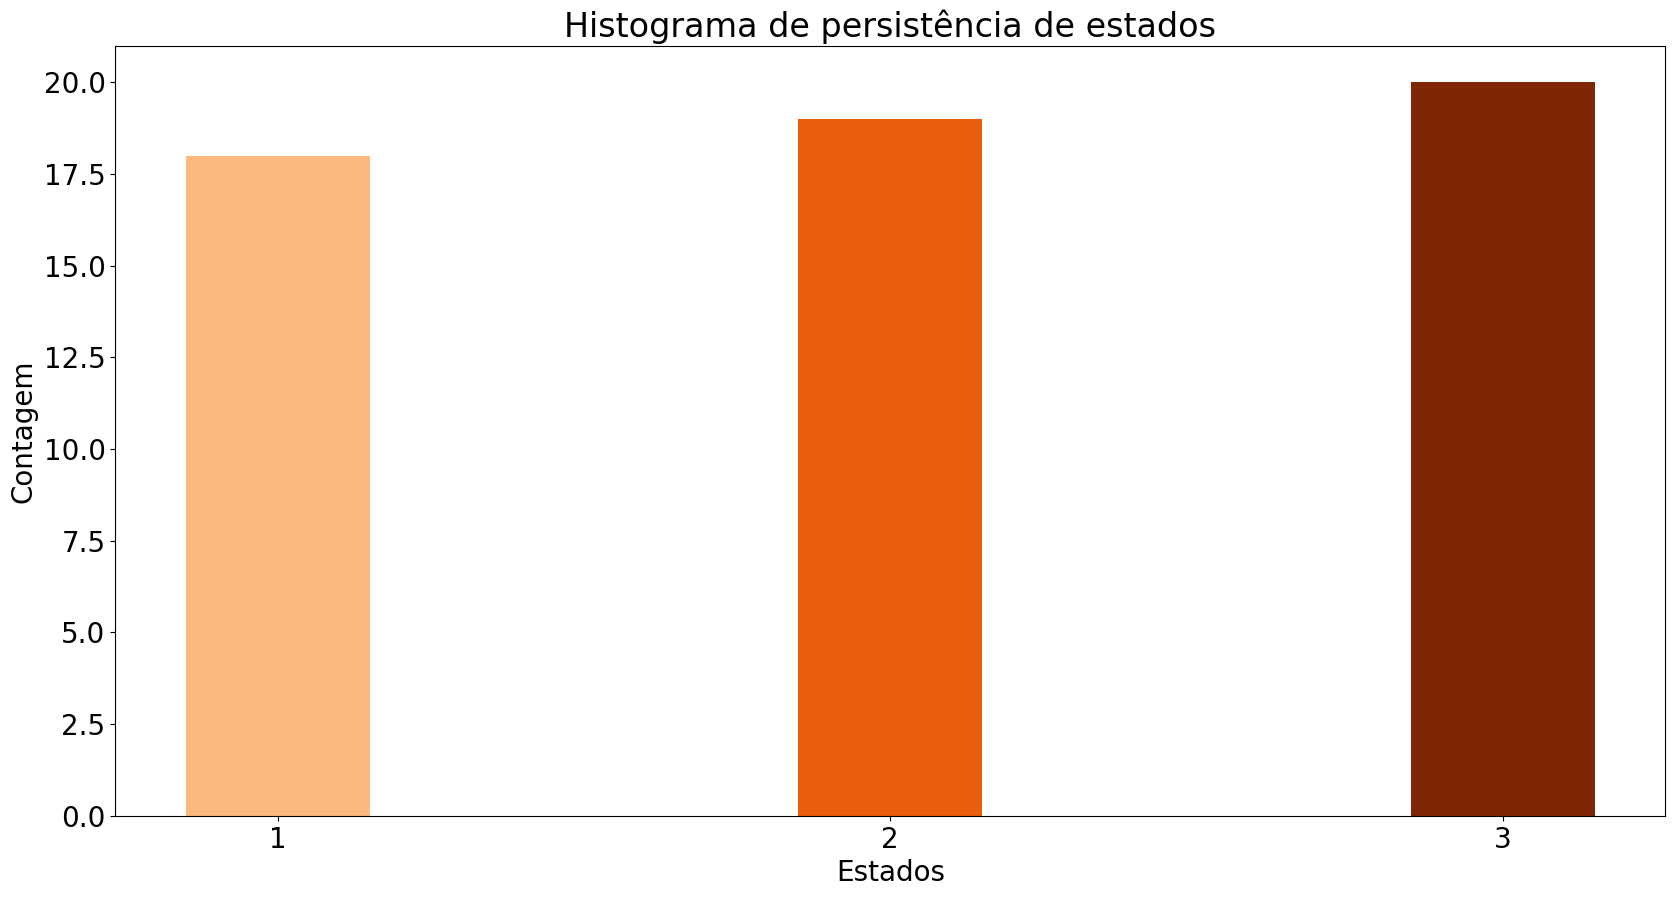

In [10]:
cmap = plt.get_cmap('Oranges', n+1)
fig,axs=plt.subplots(1,1,figsize=(20,10))
states,counts = np.unique(medianListR,return_counts=True)
axs.bar(states,counts,width=0.3,color=[cmap(i) for i in range(1,cmap.N)])
axs.set_xticks(states,np.int64(states))
axs.set_ylabel("Contagem")
axs.set_xlabel("Estados")
axs.set_title("Histograma de persistência de estados")


plt.savefig("../imagens_gerais/radius_histogram.jpg")

In [63]:
model.weights_

array([0.30963485, 0.05043931, 0.63992584])

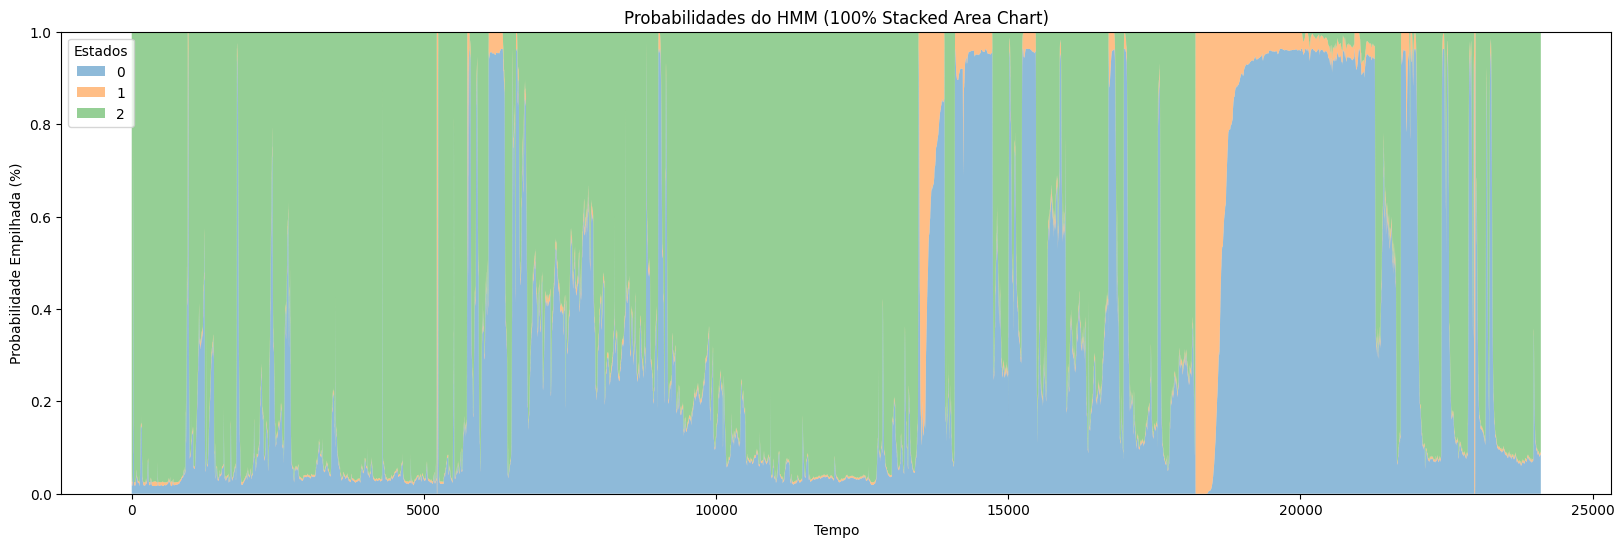

In [67]:
li.PlotHMMProbs(totalData["Radius"].loc[(totalData["Well_down"]==0) & (totalData["Well Run"]==pumpList[50])],model)

In [12]:
from scipy.stats import chisquare

# Contagens das classes ao longo das inicializações
observed_counts = np.array([counts[0],counts[1]]) # Substituir pelos valores reais
expected_counts = np.array([1/2, 1/2]) * sum(observed_counts)

# Teste qui-quadrado de aderência
chi2_stat, p_value = chisquare(f_obs=observed_counts, f_exp=expected_counts)

print(f"Estatística qui-quadrado: {chi2_stat:.4f}, p-valor: {p_value:.4f}")

if p_value < 0.05:
    print("Rejeitamos H0: C ocorre significativamente mais do que o esperado.")
else:
    print("Não há evidências suficientes para afirmar que C ocorre mais que o esperado.")


Estatística qui-quadrado: 0.0270, p-valor: 0.8694
Não há evidências suficientes para afirmar que C ocorre mais que o esperado.


In [13]:
# cmap = plt.get_cmap('Oranges', n)
# plt.figure(figsize=(7,5))

# states,counts = np.unique(medianListR,return_counts=True)
# plt.bar(states,counts,width=0.3, color=[cmap(i) for i in range(1,cmap.N)])
# plt.xticks(states,np.int64(states))
# plt.ylabel("Counts")
# plt.xlabel("States")
# plt.title("Vibration Modulus Persistence Histogram")
# plt.savefig("../imagens_gerais/vibration_histogram.jpg")

In [14]:
# # Contagens das classes ao longo das inicializações
# observed_counts = counts  # Substituir pelos valores reais
# expected_counts = np.array([1/3, 1/3, 1/3]) * sum(observed_counts)

# # Teste qui-quadrado de aderência
# chi2_stat, p_value = chisquare(f_obs=observed_counts, f_exp=expected_counts)

# print(f"Estatística qui-quadrado: {chi2_stat:.4f}, p-valor: {p_value:.4f}")

# if p_value < 0.05:
#     print("Rejeitamos H0: C ocorre significativamente mais do que o esperado.")
# else:
#     print("Não há evidências suficientes para afirmar que C ocorre mais que o esperado.")


In [15]:
for pump in pumpList:
   
    pumpData = totalData.loc[totalData["Well Run"]==pump].copy()

    # fig, axs =li.HMMPicture(
    #     pumpData,
    #     pump,
    #     props=[PCAHeaders,vibeHeader],
    #     states=["State Radius","State Mod"],
    #     numberOfStates=n,
    #     figsize=(40,15)
    #     )

    # fig.savefig("../imagensFinaisHMM/heatmap-"+pump+".png")
    # plt.close()
    onlineData = pumpData.loc[pumpData["Well_down"]==0]
    plt.figure(figsize=(10,10))
    plt.scatter(onlineData["Water Cut @ 20degC - 1 atm"],onlineData["Choke Closed"],c=onlineData["State Radius"],s=onlineData["Radius"])
    plt.xlabel("Water Cut @ 20degC - 1 atm")
    plt.ylabel("Choke Closed")
    plt.savefig("../choke_per_watercut/"+pump+".png")
    plt.close()


Text(0, 0.5, 'Choke Closed')

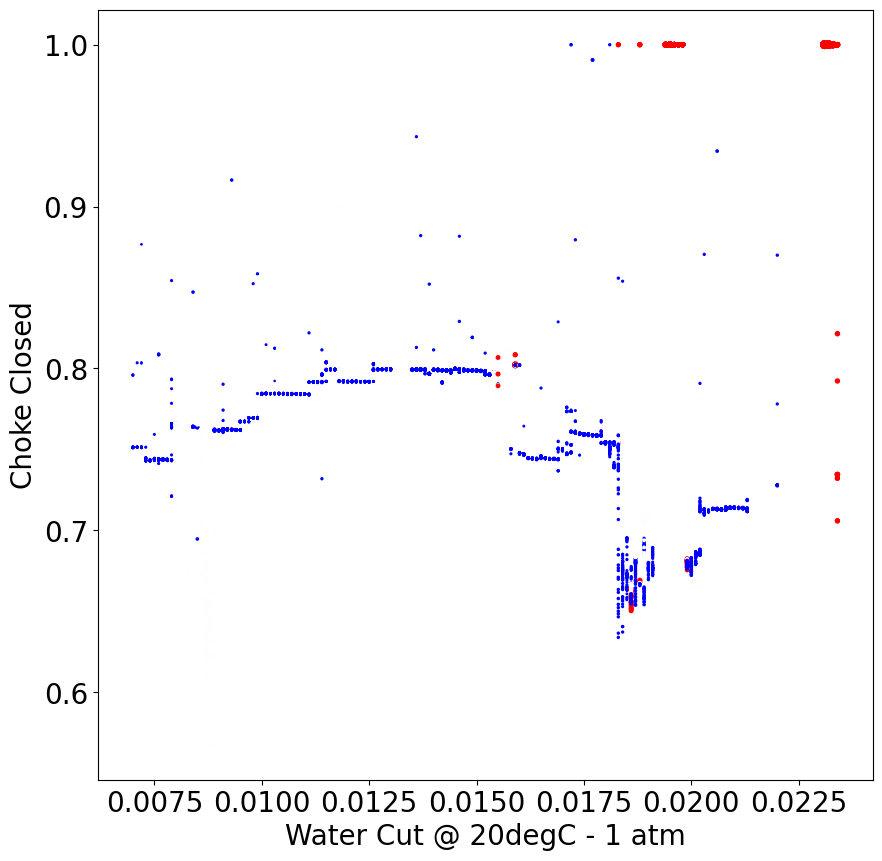

In [16]:
onlineData = totalData.loc[(totalData["Well_down"]==0) & (totalData["Well Run"]==pumpList[0]) ]

x = onlineData["Water Cut @ 20degC - 1 atm"]#.apply(np.exp))
y = onlineData["Choke Closed"]#.apply(np.exp))

plt.figure(figsize=(10,10))
plt.scatter(x,y,c=onlineData["State Radius"],s=onlineData["Radius"],cmap='bwr')
plt.xlabel("Water Cut @ 20degC - 1 atm")
plt.ylabel("Choke Closed")
# plt.savefig("../choke_per_watercut/"+pump+".png")
# plt.close()

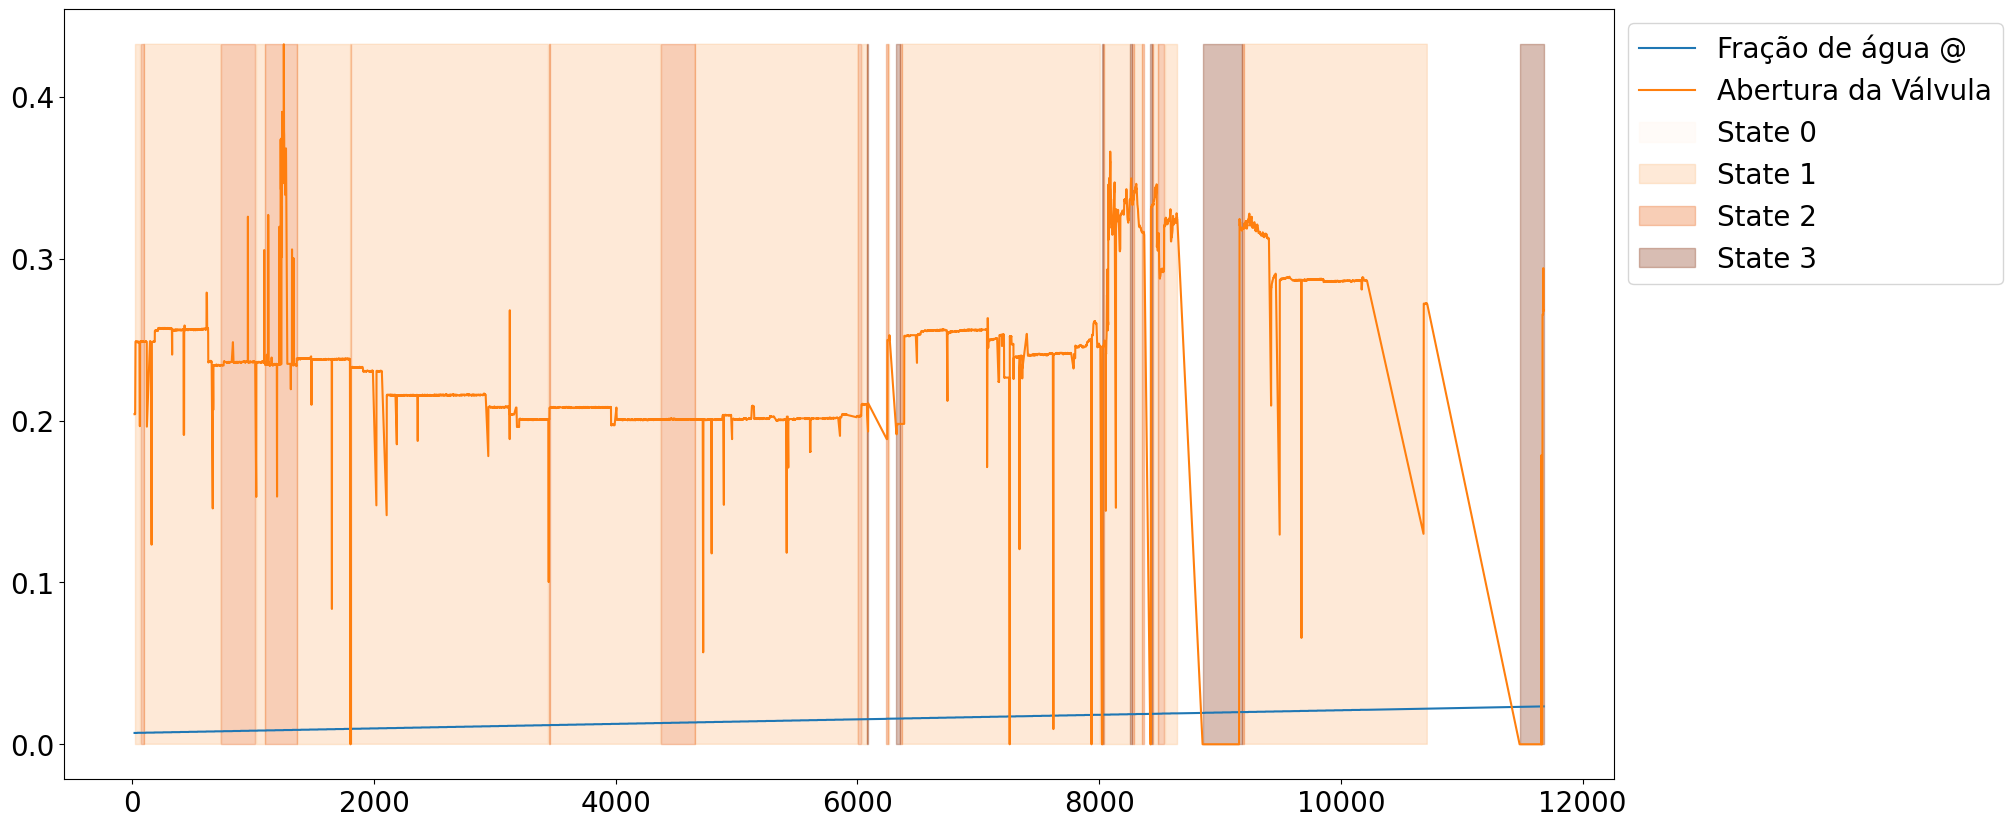

In [17]:
fig,axs = plt.subplots(1,1,figsize=(20,10))

onlineData[["Water Cut @ 20degC - 1 atm","Choke Opening"]].plot(ax=axs)
li.OverFill(onlineData,["Water Cut @ 20degC - 1 atm","Choke Opening"],"State Radius",3,axs)
#.pow(2).sum(axis=1).pow(1/2).div(np.sqrt(2))

In [18]:
gmmData = totalData[Headers].loc[totalData["Well_down"]==0].abs().apply(np.log1p)
gmmTotal = li.GaussianMixtureFit(gmmData,2,seed=mainSeed)

GMM AIC: 3524767.8528037225
GMM BIC: 3526293.984575117


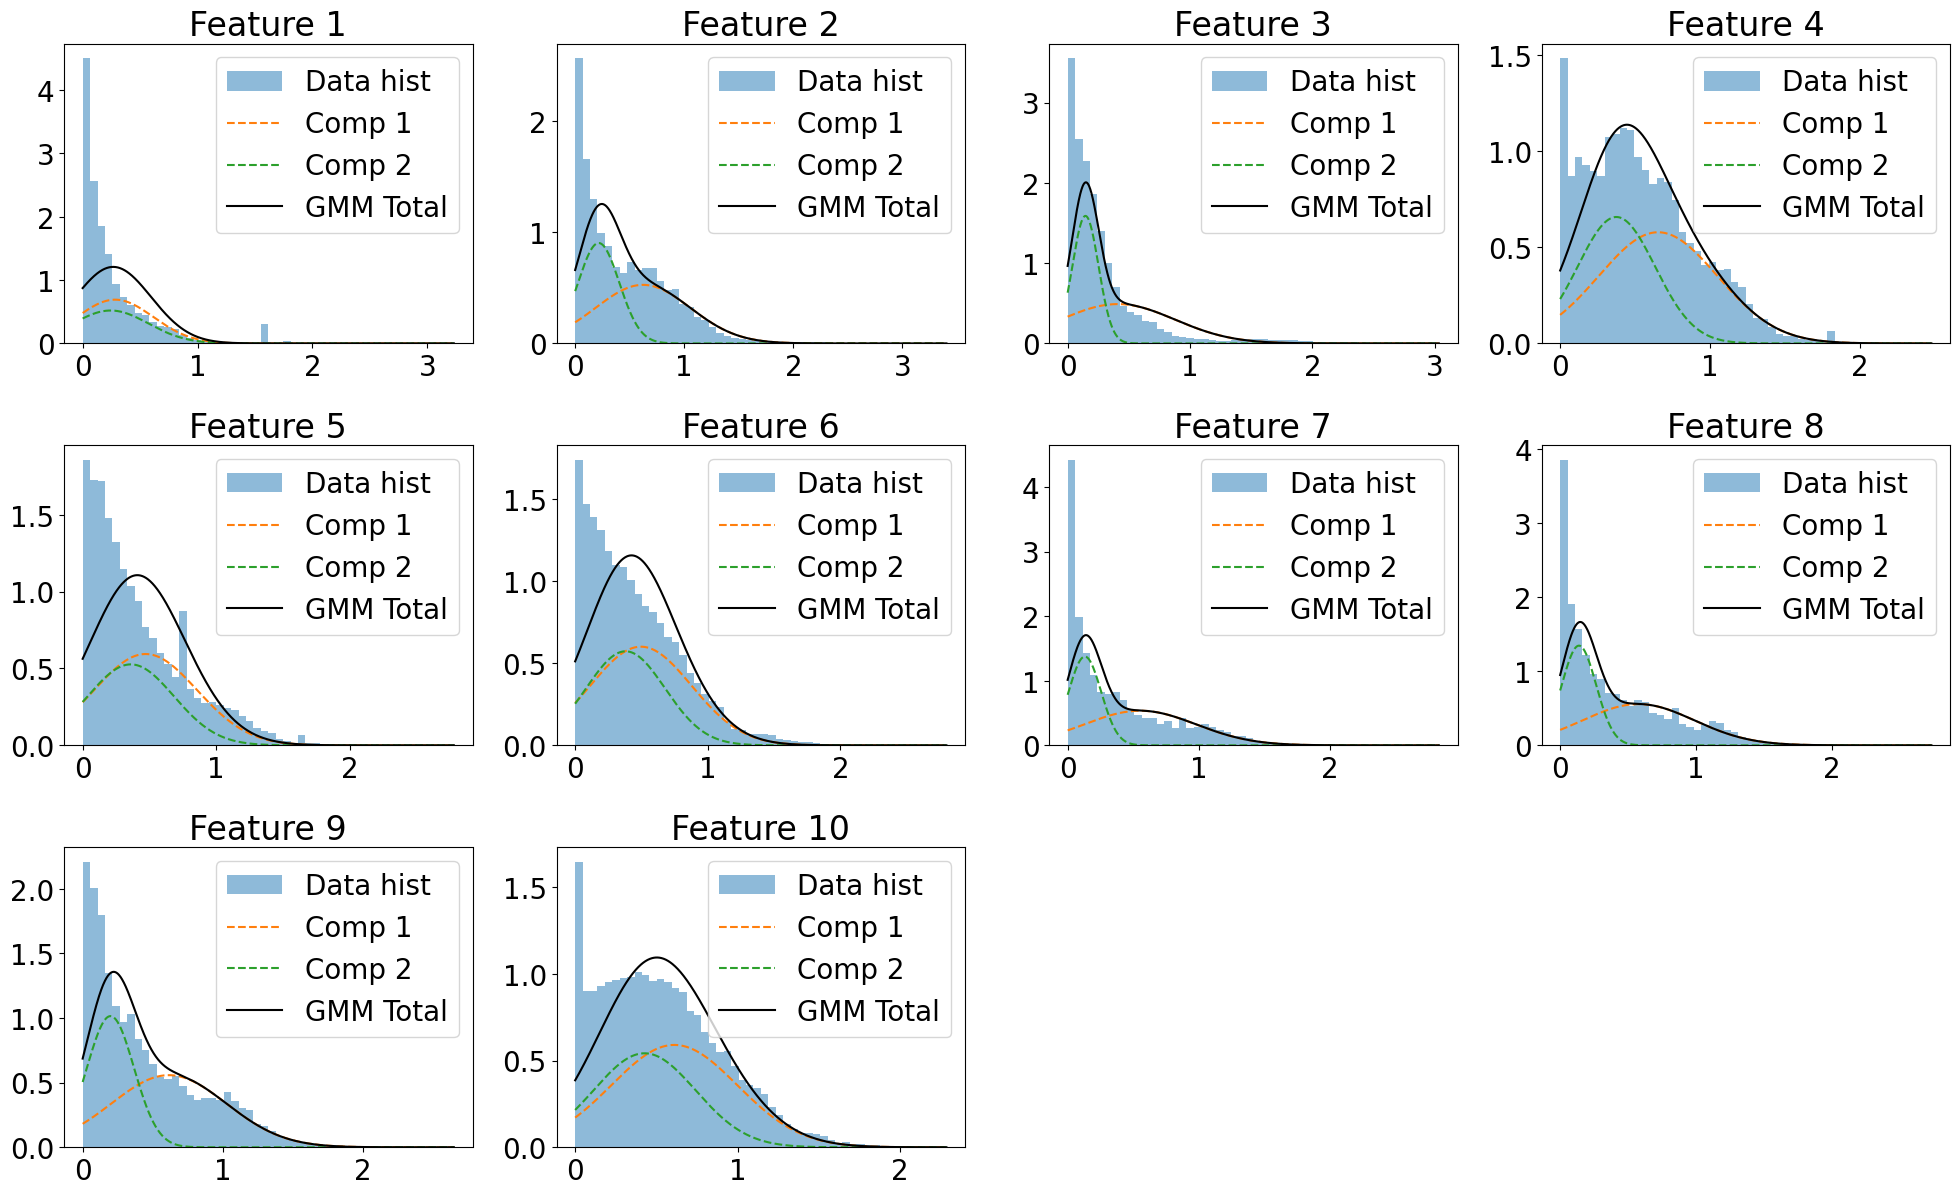

In [19]:
# plt.rcParams['font.size'] = 15.0
# plt.rcParams.update({
#     'font.size': plt.rcParams['font.size'] * 0.7,
# })
li.PlotGMMMarginals(gmmTotal,gmmData.to_numpy())

In [20]:
gmmTotal.means_

array([[0.28265501, 0.62148378, 0.4096431 , 0.65267712, 0.47153643,
        0.49547101, 0.55320342, 0.57606691, 0.61454208, 0.60998168],
       [0.24391189, 0.21558334, 0.14543791, 0.37465677, 0.36057206,
        0.37993631, 0.13132939, 0.13826133, 0.19814232, 0.42673263]])

In [21]:
# #modelSq = li.HiddenMarkovModel(X_train["Transformed Radius"], trainLength, mainSeed, n[0],covar_type="diag")
# # pickle.dump(modelSq,open("MLmodels/modelSq.sav","wb"))

# modelSq = pickle.load(open("MLmodels/modelSq.sav","rb"))

# li.PostProcessing(modelSq, PCAData, modelData,"Transformed Radius", "State Gaussian", totalLength)
# print(modelSq.get_stationary_distribution())
# PCAData["State Gaussian"] = PCAData["State Gaussian"].map(li.StateConversion(modelSq.get_stationary_distribution(),n[0]))

# #modelVib = li.HiddenMarkovModel(X_train[["VibNormX","VibNormY"]], trainLength, mainSeed, n[1],covar_type="full")
# # pickle.dump(modelVib,open("MLmodels/modelVib.sav","wb"))

# modelVib = pickle.load(open("MLmodels/modelVib.sav","rb"))
# li.PostProcessing(modelVib, PCAData, modelData,["VibNormX","VibNormY"], "State Vib", totalLength)
# print(modelVib.get_stationary_distribution())
# PCAData["State Vib"] = PCAData["State Vib"].map(li.StateConversion(modelVib.get_stationary_distribution(),n[1]))

# #modelTot = li.HiddenMarkovModel(X_train[["VibNormX","VibNormY","Transformed Radius"]], trainLength, mainSeed, n[2],covar_type="full")
# #pickle.dump(modelTot,open("MLmodels/modelTot.sav","wb"))

# modelTot = pickle.load(open("MLmodels/modelTot.sav","rb"))
# li.PostProcessing(modelTot, PCAData, modelData,["VibNormX","VibNormY","Transformed Radius"], "State Tot", totalLength)
# print(modelTot.get_stationary_distribution())
# PCAData["State Tot"] = PCAData["State Tot"].map(li.StateConversion(modelTot.get_stationary_distribution(),n[2]))


# for pump in pumpList:
#     pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()
#     fig,axs = li.HMMPicture(pumpData,pump,PCAHeaders,n)
#     fig.savefig("../imagensHMM/"+pump)
#     plt.close()

In [22]:
# numberOfDays = 7

# stats = pd.DataFrame(columns=["State Vib", "State Gaussian","State Tot"])

# for pump in pumpList:
#     pumpData = PCAData.loc[PCAData["Well Run"]==pump]
#     if pumpData.loc[pumpData["Failure"]==1].empty != True:
#         failure = pumpData.loc[pumpData["Failure"]==1].index[0]
#         indexRef = pumpData.index[0]
#         selectedData = pumpData.iloc[failure-indexRef-numberOfDays*24:]

#         stats = pd.concat([stats, 
#                        selectedData.loc[selectedData["Well_down"]==0][["State Vib", "State Gaussian","State Tot"]]])

    

In [23]:
# stats.reset_index(inplace=True,drop=True)
# stats = stats.infer_objects()
# stats.drop(labels=0,inplace=True)
# stats.hist()


In [24]:
# modelSq = li.HiddenMarkovModel(X_train["Transformed Radius"], trainLength, mainSeed, n[0],algorithm="map")
# li.PostProcessing(modelSq, PCAData, modelData,"Transformed Radius", "State Gaussian", totalLength)
# print(modelSq.get_stationary_distribution())
# PCAData["State Gaussian"] = PCAData["State Gaussian"].map(li.StateConversion(modelSq.get_stationary_distribution(),n[0]))
# pickle.dump(modelSq,open("modelSq_map.sav","wb"))

# modelVib = li.HiddenMarkovModel(X_train[["VibNormX","VibNormY"]], trainLength, mainSeed, n[1],algorithm="map")
# li.PostProcessing(modelVib, PCAData, modelData,["VibNormX","VibNormY"], "State Vib", totalLength)
# print(modelVib.get_stationary_distribution())
# PCAData["State Vib"] = PCAData["State Vib"].map(li.StateConversion(modelVib.get_stationary_distribution(),n[1]))
# pickle.dump(modelVib,open("modelVib_map.sav","wb"))

# modelTot = li.HiddenMarkovModel(X_train[["VibNormX","VibNormY","Transformed Radius"]], trainLength, mainSeed, n[2],algorithm="map")
# li.PostProcessing(modelTot, PCAData, modelData,["VibNormX","VibNormY","Transformed Radius"], "State Tot", totalLength)
# print(modelTot.get_stationary_distribution())
# PCAData["State Tot"] = PCAData["State Tot"].map(li.StateConversion(modelTot.get_stationary_distribution(),n[2]))
# pickle.dump(modelTot,open("modelTot.sav","wb"))

# for pump in pumpList:
#     pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()
#     fig,axs = li.HMMPicture(pumpData,pump,PCAHeaders,n)
#     fig.savefig("../imagensHMM_map/"+pump)
#     plt.close()

In [25]:
# pump = pumpList[0]

# pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()
# fig,axs = li.HMMPicture(pumpData,pump,PCAHeaders,n)